In [2]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [3]:
!pip install geopandas shapely pandas pyarrow tqdm fiona pyproj

In [4]:
from google.colab import files
uploaded = files.upload()

Saving village_2710010.geojson to village_2710010.geojson


In [5]:
import geopandas as gpd

# Read uploaded village file
gdf = gpd.read_file("village_2710010.geojson")

# Convert CRS to lat/lon
gdf = gdf.to_crs(epsg=4326)

# Merge ALL polygons
merged_geom = gdf.geometry.union_all()

# Convert to WKT
your_own_wkt_polygon = merged_geom.wkt

print("✅ Full village polygon ready")

✅ Full village polygon ready


In [6]:
your_own_wkt_polygon

'POLYGON ((80.93996328955343 17.27461340524291, 80.9399353225794 17.275862128264254, 80.93991210799476 17.27689865750192, 80.93985318390862 17.277625297089354, 80.93979122281162 17.278389388463722, 80.93966758651584 17.279388465914455, 80.93963772931586 17.27962973531723, 80.9394569116983 17.279755036009153, 80.93901674550233 17.28006005763528, 80.93815033036964 17.280285179897604, 80.9369681004468 17.280592360906773, 80.93689699738002 17.281151634739558, 80.93685483589783 17.281483263385176, 80.93680084984649 17.28245718588086, 80.93677548280851 17.28291480356466, 80.93673287250851 17.28368348719314, 80.93667774620128 17.28467797238976, 80.93667487758924 17.284729722495296, 80.93659898561695 17.28644114121486, 80.93652079881318 17.28820431003996, 80.93651424583892 17.28835208433629, 80.93644912995349 17.28996747886506, 80.93639858134591 17.29122148844468, 80.93634070897113 17.29173064769016, 80.93632025732009 17.291910580641847, 80.93618557643404 17.29309549927277, 80.93626267763236 1

In [ ]:
### Step 1. Prepare a compressed CSV file using [Open Buildings](https://sites.research.google/open-buildings/) data [takes 1-15 minutes depending on the region]

In [7]:
#@markdown First, select a region from either the [Natural Earth low res](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries/) (fastest), [Natural Earth high res](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/) or [World Bank high res](https://datacatalog.worldbank.org/dataset/world-bank-official-boundaries) shapefiles:
region_border_source = 'Natural Earth (Low Res 110m)'  #@param ["Natural Earth (Low Res 110m)", "Natural Earth (High Res 10m)", "World Bank (High Res 10m)"]
region = "IND (India)"  # @param ["", "ABW (Aruba)", "AGO (Angola)", "AIA (Anguilla)", "ARG (Argentina)", "ATG (Antigua and Barbuda)", "BDI (Burundi)", "BEN (Benin)", "BFA (Burkina Faso)", "BGD (Bangladesh)", "BHS (The Bahamas)", "BLM (Saint Barthelemy)", "BLZ (Belize)", "BOL (Bolivia)", "BRA (Brazil)", "BRB (Barbados)", "BRN (Brunei)", "BTN (Bhutan)", "BWA (Botswana)", "CAF (Central African Republic)", "CHL (Chile)", "CIV (Ivory Coast)", "CMR (Cameroon)", "COD (Democratic Republic of the Congo)", "COG (Republic of Congo)", "COL (Colombia)", "COM (Comoros)", "CPV (Cape Verde)", "CRI (Costa Rica)", "CUB (Cuba)", "CUW (Cura\u00e7ao)", "CYM (Cayman Islands)", "DJI (Djibouti)", "DMA (Dominica)", "DOM (Dominican Republic)", "DZA (Algeria)", "ECU (Ecuador)", "EGY (Egypt)", "ERI (Eritrea)", "ETH (Ethiopia)", "FLK (Falkland Islands)", "GAB (Gabon)", "GHA (Ghana)", "GIN (Guinea)", "GMB (Gambia)", "GNB (Guinea Bissau)", "GNQ (Equatorial Guinea)", "GRD (Grenada)", "GTM (Guatemala)", "GUY (Guyana)", "HND (Honduras)", "HTI (Haiti)", "IDN (Indonesia)", "IND (India)", "IOT (British Indian Ocean Territory)", "JAM (Jamaica)", "KEN (Kenya)", "KHM (Cambodia)", "KNA (Saint Kitts and Nevis)", "LAO (Laos)", "LBR (Liberia)", "LCA (Saint Lucia)", "LKA (Sri Lanka)", "LSO (Lesotho)", "MAF (Saint Martin)", "MDG (Madagascar)", "MDV (Maldives)", "MEX (Mexico)", "MOZ (Mozambique)", "MRT (Mauritania)", "MSR (Montserrat)", "MUS (Mauritius)", "MWI (Malawi)", "MYS (Malaysia)", "MYT (Mayotte)", "NAM (Namibia)", "NER (Niger)", "NGA (Nigeria)", "NIC (Nicaragua)", "NPL (Nepal)", "PAN (Panama)", "PER (Peru)", "PHL (Philippines)", "PRI (Puerto Rico)", "PRY (Paraguay)", "RWA (Rwanda)", "SDN (Sudan)", "SEN (Senegal)", "SGP (Singapore)", "SHN (Saint Helena)", "SLE (Sierra Leone)", "SLV (El Salvador)", "SOM (Somalia)", "STP (Sao Tome and Principe)", "SUR (Suriname)", "SWZ (Eswatini)", "SXM (Sint Maarten)", "SYC (Seychelles)", "TCA (Turks and Caicos Islands)", "TGO (Togo)", "THA (Thailand)", "TLS (East Timor)", "TTO (Trinidad and Tobago)", "TUN (Tunisia)", "TZA (United Republic of Tanzania)", "UGA (Uganda)", "URY (Uruguay)", "VCT (Saint Vincent and the Grenadines)", "VEN (Venezuela)", "VGB (British Virgin Islands)", "VIR (United States Virgin Islands)", "VNM (Vietnam)", "ZAF (South Africa)", "ZMB (Zambia)", "ZWE (Zimbabwe)"]
#@markdown **or** specify an area of interest in [WKT format](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry) (assumes crs='EPSG:4326'); this [tool](https://arthur-e.github.io/Wicket/sandbox-gmaps3.html) might be useful.
your_own_wkt_polygon = your_own_wkt_polygon  #@param {type:"string"}
#@markdown Select type of data to download here:
data_type = 'polygons'  #@param ["polygons", "points"]

!sudo apt-get install swig
!pip install s2geometry geopandas
import s2geometry as s2

# ✅ Fix broken s2geometry API
s2.S2LatLng_FromDegrees       = s2.S2LatLng.FromDegrees
s2.S2LatLngRect_FromPointPair = s2.S2LatLngRect.FromPointPair
s2.S2CellId_FromToken         = lambda token, _len=None: s2.S2CellId.FromToken(token)

print("✅ Shim applied")
import functools
import glob
import gzip
import multiprocessing
import os
import shutil
import tempfile
from typing import List, Optional, Tuple

import geopandas as gpd
from IPython import display
import pandas as pd
import s2geometry as s2
import shapely
import tensorflow as tf
import tqdm.notebook

BUILDING_DOWNLOAD_PATH = ('gs://open-buildings-data/v3/'
                          f'{data_type}_s2_level_6_gzip_no_header')

def get_filename_and_region_dataframe(
    region_border_source: str, region: str,
    your_own_wkt_polygon: str) -> Tuple[str, gpd.geodataframe.GeoDataFrame]:
  """Returns output filename and a geopandas dataframe with one region row."""

  if your_own_wkt_polygon:
    filename = f'open_buildings_v3_{data_type}_your_own_wkt_polygon.csv.gz'
    region_df = gpd.GeoDataFrame(
        geometry=gpd.GeoSeries.from_wkt([your_own_wkt_polygon]),
        crs='EPSG:4326')
    if not isinstance(region_df.iloc[0].geometry,
                      shapely.geometry.polygon.Polygon) and not isinstance(
                          region_df.iloc[0].geometry,
                          shapely.geometry.multipolygon.MultiPolygon):
      raise ValueError("`your_own_wkt_polygon` must be a POLYGON or "
                      "MULTIPOLYGON.")
    print(f'Preparing your_own_wkt_polygon.')
    return filename, region_df

  if not region:
    raise ValueError('Please select a region or set your_own_wkt_polygon.')

  if region_border_source == 'Natural Earth (Low Res 110m)':
    url = ('https://naciscdn.org/naturalearth/'
           '110m/cultural/ne_110m_admin_0_countries.zip')
    !wget -N {url}
    display.clear_output()
    region_shapefile_path = os.path.basename(url)
    source_name = 'ne_110m'
  elif region_border_source == 'Natural Earth (High Res 10m)':
    url = ('https://naciscdn.org/naturalearth/'
           '10m/cultural/ne_10m_admin_0_countries.zip')
    !wget -N {url}
    display.clear_output()
    region_shapefile_path = os.path.basename(url)
    source_name = 'ne_10m'
  elif region_border_source == 'World Bank (High Res 10m)':
    url = ('https://datacatalogfiles.worldbank.org/ddh-published/'
           '0038272/DR0046659/wb_countries_admin0_10m.zip')
    !wget -N {url}
    !unzip -o {os.path.basename(url)}
    display.clear_output()
    region_shapefile_path = 'WB_countries_Admin0_10m'
    source_name = 'wb_10m'

  region_iso_a3 = region.split(' ')[0]
  filename = (f'open_buildings_v3_{data_type}_'
              f'{source_name}_{region_iso_a3}.csv.gz')
  region_df = gpd.read_file(region_shapefile_path).query(
      f'ISO_A3 == "{region_iso_a3}"').dissolve(by='ISO_A3')[['geometry']]
  print(f'Preparing {region} from {region_border_source}.')
  return filename, region_df


def get_bounding_box_s2_covering_tokens(
    region_geometry: shapely.geometry.base.BaseGeometry) -> List[str]:
  region_bounds = region_geometry.bounds
  s2_lat_lng_rect = s2.S2LatLngRect_FromPointPair(
      s2.S2LatLng_FromDegrees(region_bounds[1], region_bounds[0]),
      s2.S2LatLng_FromDegrees(region_bounds[3], region_bounds[2]))
  coverer = s2.S2RegionCoverer()
  # NOTE: Should be kept in-sync with s2 level in BUILDING_DOWNLOAD_PATH.
  coverer.set_fixed_level(6)
  coverer.set_max_cells(1000000)
  return [cell.ToToken() for cell in coverer.GetCovering(s2_lat_lng_rect)]


def s2_token_to_shapely_polygon(
    s2_token: str) -> shapely.geometry.polygon.Polygon:
  s2_cell = s2.S2Cell(s2.S2CellId_FromToken(s2_token, len(s2_token)))
  coords = []
  for i in range(4):
    s2_lat_lng = s2.S2LatLng(s2_cell.GetVertex(i))
    coords.append((s2_lat_lng.lng().degrees(), s2_lat_lng.lat().degrees()))
  return shapely.geometry.Polygon(coords)


def download_s2_token(
    s2_token: str, region_df: gpd.geodataframe.GeoDataFrame) -> Optional[str]:
  """Downloads the matching CSV file with polygons for the `s2_token`.

  NOTE: Only polygons inside the region are kept.
  NOTE: Passing output via a temporary file to reduce memory usage.

  Args:
    s2_token: S2 token for which to download the CSV file with building
      polygons. The S2 token should be at the same level as the files in
      BUILDING_DOWNLOAD_PATH.
    region_df: A geopandas dataframe with only one row that contains the region
      for which to keep polygons.

  Returns:
    Either filepath which contains a gzipped CSV without header for the
    `s2_token` subfiltered to only contain building polygons inside the region
    or None which means that there were no polygons inside the region for this
    `s2_token`.
  """
  s2_cell_geometry = s2_token_to_shapely_polygon(s2_token)
  region_geometry = region_df.iloc[0].geometry
  prepared_region_geometry = shapely.prepared.prep(region_geometry)
  # If the s2 cell doesn't intersect the country geometry at all then we can
  # know that all rows would be dropped so instead we can just return early.
  if not prepared_region_geometry.intersects(s2_cell_geometry):
    return None
  try:
    # Using tf.io.gfile.GFile gives better performance than passing the GCS path
    # directly to pd.read_csv.
    with tf.io.gfile.GFile(
        os.path.join(BUILDING_DOWNLOAD_PATH, f'{s2_token}_buildings.csv.gz'),
        'rb') as gf:
      # If the s2 cell is fully covered by country geometry then can skip
      # filtering as we need all rows.
      if prepared_region_geometry.covers(s2_cell_geometry):
        with tempfile.NamedTemporaryFile(mode='w+b', delete=False) as tmp_f:
          shutil.copyfileobj(gf, tmp_f)
          return tmp_f.name
      # Else take the slow path.
      # NOTE: We read in chunks to save memory.
      csv_chunks = pd.read_csv(
          gf, chunksize=2000000, dtype=object, compression='gzip', header=None)
      tmp_f = tempfile.NamedTemporaryFile(mode='w+b', delete=False)
      tmp_f.close()
      for csv_chunk in csv_chunks:
        points = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(csv_chunk[1], csv_chunk[0]),
            crs='EPSG:4326')
        # sjoin 'within' was faster than using shapely's 'within' directly.
        points = gpd.sjoin(points, region_df, predicate='within')
        csv_chunk = csv_chunk.iloc[points.index]
        csv_chunk.to_csv(
            tmp_f.name,
            mode='ab',
            index=False,
            header=False,
            compression={
                'method': 'gzip',
                'compresslevel': 1
            })
      return tmp_f.name
  except tf.errors.NotFoundError:
    return None

# Clear output after pip install.
display.clear_output()
filename, region_df = get_filename_and_region_dataframe(region_border_source,
                                                        region,
                                                        your_own_wkt_polygon)
# Remove any old outputs to not run out of disk.
for f in glob.glob('/tmp/open_buildings_*'):
  os.remove(f)
# Write header to the compressed CSV file.
with gzip.open(f'/tmp/{filename}', 'wt') as merged:
  if data_type == "polygons":
    merged.write(','.join([
        'latitude', 'longitude', 'area_in_meters', 'confidence', 'geometry',
        'full_plus_code'
    ]) + '\n')
  else:
    merged.write(','.join([
        'latitude', 'longitude', 'area_in_meters', 'confidence',
        'full_plus_code'
    ]) + '\n')
download_s2_token_fn = functools.partial(download_s2_token, region_df=region_df)
s2_tokens = get_bounding_box_s2_covering_tokens(region_df.iloc[0].geometry)
# Downloads CSV files for relevant S2 tokens and after filtering appends them
# to the compressed output CSV file. Relies on the fact that concatenating
# gzipped files produces a valid gzip file.
# NOTE: Uses a pool to speed up output preparation.
with open(f'/tmp/{filename}', 'ab') as merged:
  with multiprocessing.Pool(4) as e:
    for fname in tqdm.notebook.tqdm(
        e.imap_unordered(download_s2_token_fn, s2_tokens),
        total=len(s2_tokens)):
      if fname:
        with open(fname, 'rb') as tmp_f:
          shutil.copyfileobj(tmp_f, merged)
        os.unlink(fname)

Preparing your_own_wkt_polygon.


  0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# ### Step 2. Access the generated CSV

# We currently support two options:

# *   Upload to your Google Drive (requires authentication) and then download manually from Google Drive [recommended, very fast]
# *   Download directly from the Colab [not recommended, very slow]

# When asked to do the authentication please follow the url, paste the generated token into the text field and press enter.



In [9]:
# ✅ Download result directly to your PC
from google.colab import files
import shutil

# Copy from /tmp to /content with proper filename
shutil.copy(f'/tmp/{filename}', f'/content/{filename}')

# Download to your PC
files.download(f'/content/{filename}')
print(f"✅ Downloading: {filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading: open_buildings_v3_polygons_your_own_wkt_polygon.csv.gz


In [12]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from google.colab import files

# ✅ Set your village ID here
village_id = "2710010"  # ← change this to your village ID

# Read the file
df = pd.read_csv(f'/content/{filename}')
print(f"✅ Total buildings: {len(df)}")
print(df.columns.tolist())

# Convert geometry column to shapely
df['geometry'] = df['geometry'].apply(wkt.loads)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

# Save as GeoJSON with village ID in filename
output_filename = f"{village_id}_building.geojson"
gdf.to_file(output_filename, driver="GeoJSON")
print(f"✅ Saved: {output_filename}")

# Download
files.download(output_filename)
print(f"✅ Downloading: {output_filename}")

✅ Total buildings: 6049
['latitude', 'longitude', 'area_in_meters', 'confidence', 'geometry', 'full_plus_code']
✅ Saved: 2710010_building.geojson


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading: 2710010_building.geojson


In [13]:
#@title Download result directly [slow]

from google.colab import files

files.download(f'/tmp/{filename}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
## water bodies

In [14]:
!pip install rasterio geopandas shapely numpy -q

In [15]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

Saving village_2710010.geojson to village_2710010 (1).geojson
✅ Uploaded: village_2710010 (1).geojson


In [16]:
import json
from shapely.geometry import shape
from shapely.ops import unary_union

with open(filename) as f:
    gj = json.load(f)

if gj['type'] == 'FeatureCollection':
    geometries = [shape(f['geometry']) for f in gj['features']]
else:
    geometries = [shape(gj['geometry'])]

village_geom = unary_union(geometries)
print(f"✅ Village loaded")
print(f"   Bounds: {village_geom.bounds}")

✅ Village loaded
   Bounds: (80.93618557643404, 17.24661497800002, 81.05204735199999, 17.328261533999978)


In [17]:
import math
import numpy as np
import rasterio
import rasterio.mask
import rasterio.features
import rasterio.merge
import geopandas as gpd
from shapely.geometry import mapping
import warnings
warnings.filterwarnings("ignore")

# --- Find tile ---
minx, miny, maxx, maxy = village_geom.bounds

def tile_name(lon, lat):
    t_lat = int(math.floor(lat / 3.0) * 3)
    t_lon = int(math.floor(lon / 3.0) * 3)
    lat_str = f"N{t_lat:02d}" if t_lat >= 0 else f"S{abs(t_lat):02d}"
    lon_str = f"E{t_lon:03d}" if t_lon >= 0 else f"W{abs(t_lon):03d}"
    return f"{lat_str}{lon_str}"

tile = tile_name(minx, miny)
url  = f"https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_{tile}_Map.tif"
print(f"✅ Tile : {tile}")
print(f"   URL  : {url}")

# --- Stream read from AWS ---
env_opts = {
    "GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR",
    "CPL_VSIL_CURL_ALLOWED_EXTENSIONS": ".tif",
    "AWS_NO_SIGN_REQUEST": "YES",
}
buf = 0.01
with rasterio.Env(**env_opts):
    with rasterio.open(f"/vsicurl/{url}") as src:
        print("✅ Tile opened")
        merged, tf = rasterio.merge.merge(
            [src],
            bounds=(minx-buf, miny-buf, maxx+buf, maxy+buf)
        )
        crs = src.crs

data = merged[0]
print(f"   Shape: {data.shape}  dtype: {data.dtype}")

✅ Tile : N15E078
   URL  : https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N15E078_Map.tif
✅ Tile opened
   Shape: (1220, 1630)  dtype: uint8


In [18]:
from rasterio.io import MemoryFile

with MemoryFile() as mem:
    with mem.open(driver="GTiff", height=data.shape[0], width=data.shape[1],
                  count=1, dtype=data.dtype, crs=crs, transform=tf) as tmp:
        tmp.write(data, 1)
    with mem.open() as src:
        clipped, tf = rasterio.mask.mask(
            src, [mapping(village_geom)],
            crop=True, nodata=0, all_touched=True
        )

clipped = clipped[0]
print("✅ Clipped to village")

✅ Clipped to village


In [19]:
WC_CLASSES = {
    10:"Tree cover", 20:"Shrubland", 30:"Grassland", 40:"Cropland",
    50:"Built-up", 60:"Bare/sparse", 70:"Snow/ice", 80:"Permanent water",
    90:"Herbaceous wetland", 95:"Mangroves", 100:"Moss/lichen"
}

print("\n🔹 Land cover inside village:")
for val, cnt in zip(*np.unique(clipped, return_counts=True)):
    if val == 0: continue
    pct = cnt * 100 / clipped.size
    print(f"  {int(val):3d}  {WC_CLASSES.get(int(val),'?'):20s}: {cnt:>6d} px  ({pct:.1f}%)")


🔹 Land cover inside village:
   10  Tree cover          : 228806 px  (16.8%)
   20  Shrubland           :    257 px  (0.0%)
   30  Grassland           :  51426 px  (3.8%)
   40  Cropland            : 104525 px  (7.7%)
   50  Built-up            :   1154 px  (0.1%)
   60  Bare/sparse         :    164 px  (0.0%)
   80  Permanent water     :    894 px  (0.1%)


In [20]:
water_mask = (clipped == 80).astype(np.uint8)
print(f"\n💧 Water pixels: {water_mask.sum()}  (~{water_mask.sum()*100/10000:.2f} ha)")

shapes_gen = rasterio.features.shapes(
    water_mask, mask=water_mask, transform=tf, connectivity=8
)
records = [{"geometry": shape(g)} for g, v in shapes_gen if v == 1]

if not records:
    print("⚠️  No water found — try lowering min_area_m2 to 100")
else:
    gdf = gpd.GeoDataFrame(records, crs=crs).to_crs("EPSG:4326")

    # Filter small + classify
    gdf_m = gdf.to_crs("EPSG:32644")
    gdf_m = gdf_m[gdf_m.geometry.area >= 500].copy()
    gdf_m["area_ha"] = (gdf_m.geometry.area / 10000).round(3)
    gdf_m["water_type"] = gdf_m["area_ha"].apply(
        lambda h: "pond" if h < 0.5 else
                  "tank" if h < 5 else
                  "lake_or_reservoir" if h < 50 else
                  "large_reservoir"
    )
    water = gdf_m.to_crs("EPSG:4326")[["geometry","water_type","area_ha"]]

    print(f"\n📊 Results:")
    print(water["water_type"].value_counts().to_string())
    print(f"\n   Total features : {len(water)}")
    print(f"   Total water    : {water['area_ha'].sum():.2f} ha")


💧 Water pixels: 894  (~8.94 ha)

📊 Results:
water_type
tank    5
pond    5

   Total features : 10
   Total water    : 7.26 ha


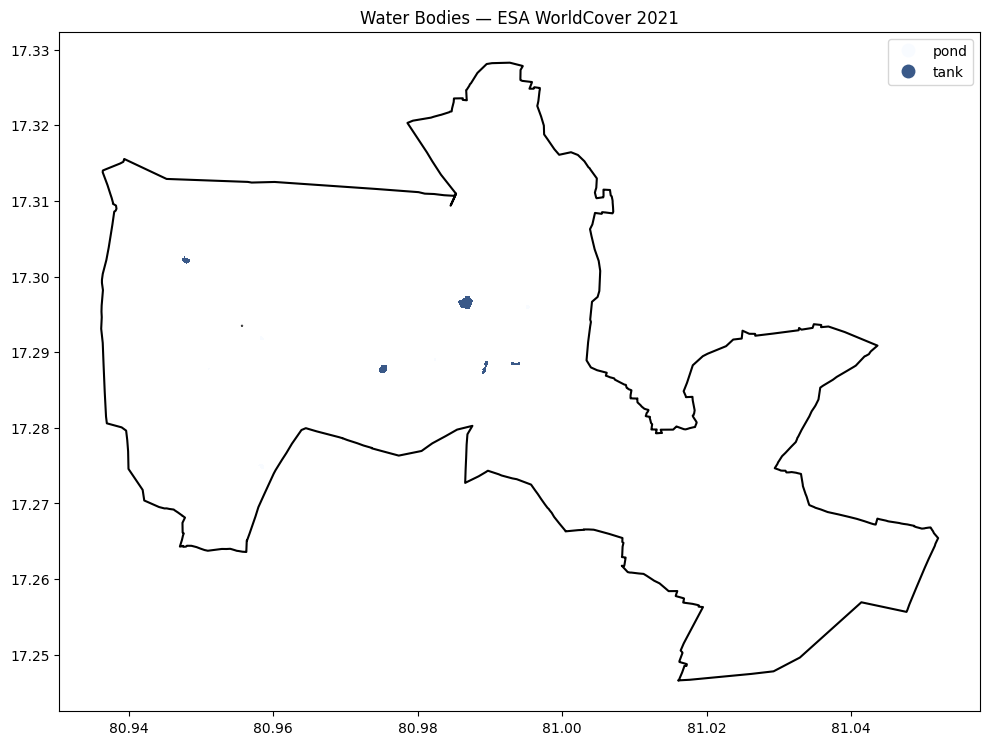

In [21]:
import matplotlib.pyplot as plt

village_gdf = gpd.GeoDataFrame(geometry=[village_geom], crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10,10))
village_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)
water.plot(ax=ax, column="water_type", legend=True, cmap="Blues", alpha=0.8)
ax.set_title("Water Bodies — ESA WorldCover 2021")
plt.tight_layout()
plt.savefig("water_map.png", dpi=150)
plt.show()

In [22]:
from google.colab import files

water.to_file("water_bodies_10.geojson", driver="GeoJSON")
files.download("water_bodies_10.geojson")
#files.download("water_map.png")
print("✅ Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
